# House Price Regression

## 1. Project Goal
The goal of this project is to build a regression model that predicts house sale prices based on property features such as size, quality, year built, rooms, garage information, and other housing characteristics.

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

## 3. Load Dataset

In [2]:
df = pd.read_csv('../data/raw/Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## 4. Basic Data Exploration

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [4]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [5]:
df.shape

(545, 13)

In [6]:
df.describe

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

In [7]:
df.isnull().sum().sort_values(ascending=False).head(20)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df["price"].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

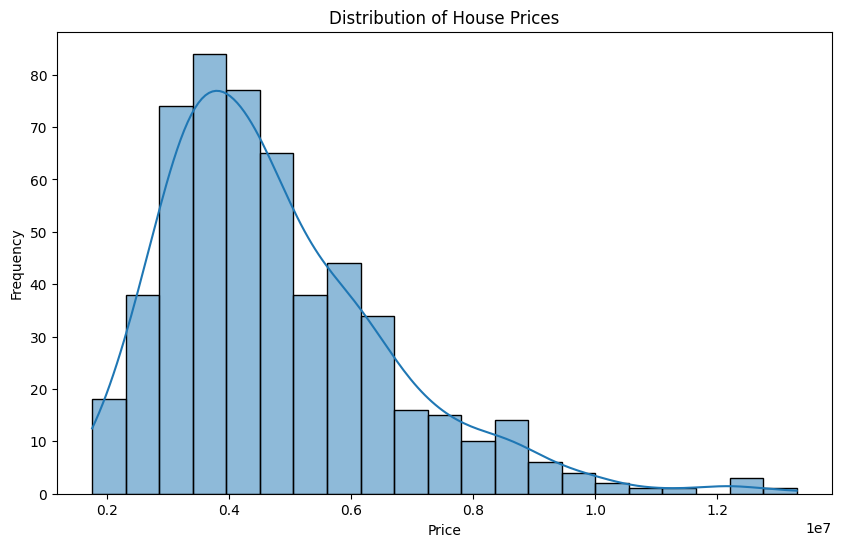

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()                                                                                                                                                                                                                                                                                                                                                 

In [10]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
correlation = numeric_df.corr()["price"].sort_values(ascending=False)                                                                                                                   
correlation.head(15)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

## 5. Data Cleaning    
The dataset does not contain missing values, so no missing-value imputation is required. For the first version of the model, only numeric features will be used to keep the workflow simple and easy to understand.                                             

In [11]:
df_clean = df.copy()
df_clean.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## 6. Feature Selection
For the first regression model, numeric features with the strongest relationship to house price are selected.

In [12]:
features = ["area", "bedrooms", "bathrooms", "stories", "parking"]
target = "price"

X = df_clean[features]
y = df_clean[target]

X.head(10)

,area,bedrooms,bathrooms,stories,parking
0,7420,4,2,3,2
1,8960,4,4,4,3
2,9960,3,2,2,2
3,7500,4,2,2,3
4,7420,4,1,2,2
5,7500,3,3,1,2
6,8580,4,3,4,2
7,16200,5,3,2,0
8,8100,4,1,2,2
9,5750,3,2,4,1


In [13]:
y.head(10)

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
5    10850000
6    10150000
7    10150000
8     9870000
9     9800000
Name: price, dtype: int64

## 7. Train/Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (436, 5)
X_test shape: (109, 5)
y_train shape: (436,)
y_test shape: (109,)


## 8. Model 1: Linear Regression
Linear Regression is used as the first baseline regression model. It tries to predict house prices by learning a linear relationship between the selected features and the target value.

In [15]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
linear_predictions = linear_model.predict(X_test)

linear_predictions[:10]

array([6178627.50326817, 6370140.85865473, 3283148.1570249 ,
       4226007.94816032, 3409685.55116741, 4262158.3499693 ,
       5493440.53152357, 5559897.74293016, 3373715.42245305,
       3020513.18649699])

In [17]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression MSE:", linear_mse)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 1127483.3523235186
Linear Regression MSE: 2292721545725.3613
Linear Regression RMSE: 1514173.552049223
Linear Regression R²: 0.5464062355495873


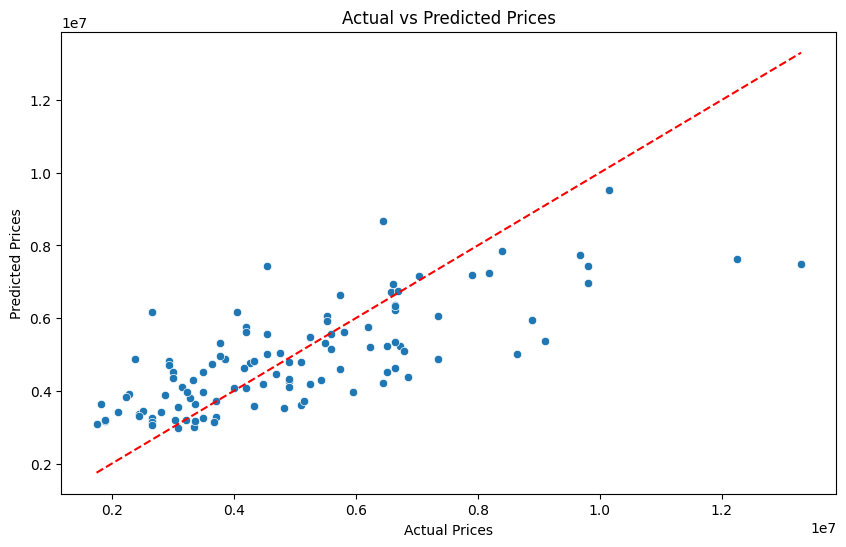

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=linear_predictions)
plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.show()

The Linear Regression model achieved an R² score of about 0.55, meaning it explains around 55% of the variation in house prices using the selected numeric features. The RMSE is about 1.51 million, which shows that the model still has significant prediction error. This model will be used as the baseline regression model for comparison with the Decision Tree Regressor.

## 9. Model 2: Decision Tree Regressor
A Decision Tree Regressor is used as the second regression model. This model learns rule-based patterns from the training data and predicts house prices based on feature splits.

In [20]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)
tree_predictions[:10]

array([8400000., 5880000., 3356500., 4620000., 2660000., 5040000.,
       5250000., 3850000., 2380000., 2660000.])

In [21]:
tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_mse = mean_squared_error(y_test, tree_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree MAE:", tree_mae)
print("Decision Tree MSE:", tree_mse)
print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R²:", tree_r2)

Decision Tree MAE: 1462106.0550458715
Decision Tree MSE: 4485381933539.653
Decision Tree RMSE: 2117872.0295475014
Decision Tree R²: 0.11260864625039191


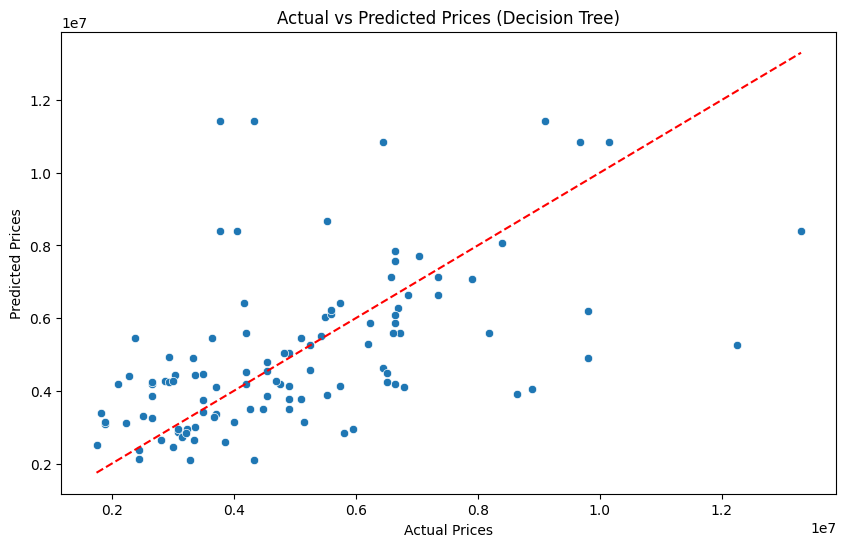

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=tree_predictions)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Actual vs Predicted Prices (Decision Tree)")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()

The Decision Tree Regressor achieved an R² score of about 0.11, which is much lower than the Linear Regression model. Its RMSE is also higher, meaning it made larger prediction errors. This suggests that the basic Decision Tree model did not generalize well on the test data and likely overfit the training data.

## 10. Model Improvement: Adding Categorical Features

The first version of the models used only numeric features. In this section, categorical housing features are added using one-hot encoding to see whether model performance improves.

In [26]:
improved_features = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking",
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

X_improved = df_clean[improved_features]
y_improved = df_clean[target]

X_improved = pd.get_dummies(X_improved, drop_first=True)
X_improved.head(10)

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,7420,4,1,2,2,True,True,True,False,True,False,False,False
5,7500,3,3,1,2,True,False,True,False,True,True,True,False
6,8580,4,3,4,2,True,False,False,False,True,True,True,False
7,16200,5,3,2,0,True,False,False,False,False,False,False,True
8,8100,4,1,2,2,True,True,True,False,True,True,False,False
9,5750,3,2,4,1,True,True,False,False,True,True,False,True


In [27]:
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X_improved, y_improved, test_size=0.2, random_state=42)

print("X_train_imp shape:", X_train_imp.shape)
print("X_test_imp shape:", X_test_imp.shape)
print("y_train_imp shape:", y_train_imp.shape)
print("y_test_imp shape:", y_test_imp.shape)

X_train_imp shape: (436, 13)
X_test_imp shape: (109, 13)
y_train_imp shape: (436,)
y_test_imp shape: (109,)


In [29]:
improved_linear_model = LinearRegression()
improved_linear_model.fit(X_train_imp, y_train_imp)

improved_linear_predictions = improved_linear_model.predict(X_test_imp)

improved_linear_mae = mean_absolute_error(y_test_imp, improved_linear_predictions)
improved_linear_mse = mean_squared_error(y_test_imp, improved_linear_predictions)
improved_linear_rmse = np.sqrt(improved_linear_mse)
improved_linear_r2 = r2_score(y_test_imp, improved_linear_predictions)  

print("Improved Linear Regression MAE:", improved_linear_mae)
print("Improved Linear Regression MSE:", improved_linear_mse)
print("Improved Linear Regression RMSE:", improved_linear_rmse)
print("Improved Linear Regression R²:", improved_linear_r2)

Improved Linear Regression MAE: 970043.4039201637
Improved Linear Regression MSE: 1754318687330.6643
Improved Linear Regression RMSE: 1324506.9600914388
Improved Linear Regression R²: 0.6529242642153184


In [30]:
improved_tree_model = DecisionTreeRegressor(max_depth=5,random_state=42)
improved_tree_model.fit(X_train_imp, y_train_imp)

improved_tree_predictions = improved_tree_model.predict(X_test_imp)

improved_tree_mae = mean_absolute_error(y_test_imp, improved_tree_predictions)
improved_tree_mse = mean_squared_error(y_test_imp, improved_tree_predictions)
improved_tree_rmse = np.sqrt(improved_tree_mse)
improved_tree_r2 = r2_score(y_test_imp, improved_tree_predictions)

print("Improved Decision Tree MAE:", improved_tree_mae)
print("Improved Decision Tree MSE:", improved_tree_mse)
print("Improved Decision Tree RMSE:", improved_tree_rmse)
print("Improved Decision Tree R²:", improved_tree_r2)


Improved Decision Tree MAE: 1230810.4867181955
Improved Decision Tree MSE: 2701167171509.852
Improved Decision Tree RMSE: 1643522.7931214864
Improved Decision Tree R²: 0.46559904406211106


After adding categorical features with one-hot encoding, both models improved. Linear Regression improved from an R² score of 0.55 to 0.65, while the Decision Tree Regressor improved from 0.11 to 0.47. This shows that categorical housing features such as air conditioning, preferred area, and furnishing status contain useful information for predicting house prices.

## 11. Model Comparison
In this section, the basic and improved regression models are compared using MAE, RMSE, and R² score.

In [35]:
model_results = pd.DataFrame({
    "Model": ["Basic Linear Regression", "Basic Decision Tree", "Improved Linear Regression", "Improved Decision Tree"],
    "MAE": [linear_mae, tree_mae, improved_linear_mae, improved_tree_mae],
    "MSE": [linear_mse, tree_mse, improved_linear_mse, improved_tree_mse],
    "RMSE": [linear_rmse, tree_rmse, improved_linear_rmse, improved_tree_rmse],
    "R2 Score": [linear_r2, tree_r2, improved_linear_r2, improved_tree_r2]
})

model_results

,Model,MAE,MSE,RMSE,R2 Score
0,Basic Linear Regression,1.127483e+06,2.292722e+12,1.514174e+06,0.546406
1,Basic Decision Tree,1.462106e+06,4.485382e+12,2.117872e+06,0.112609
2,Improved Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
3,Improved Decision Tree,1.230810e+06,2.701167e+12,1.643523e+06,0.465599


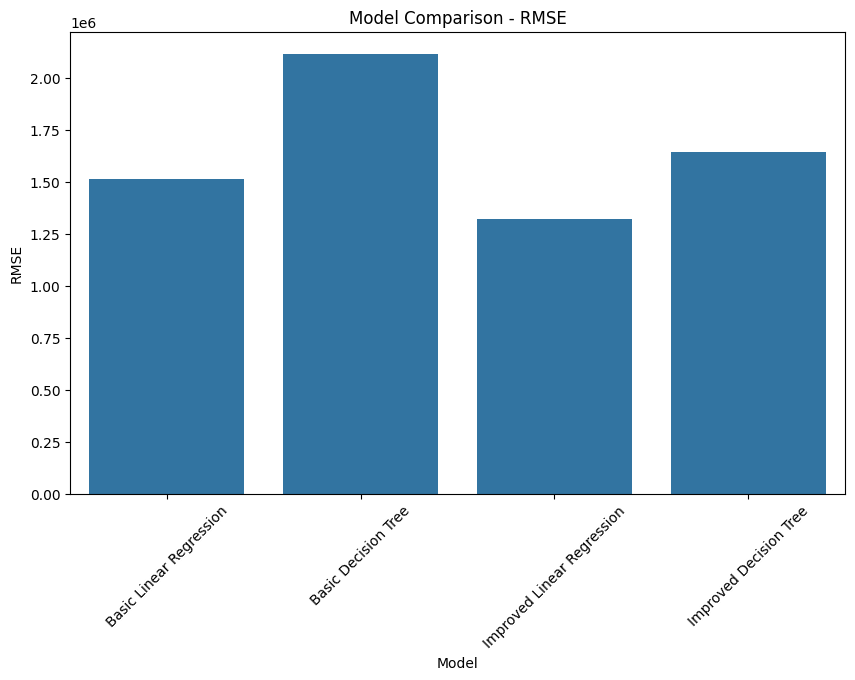

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="RMSE", data=model_results)
plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

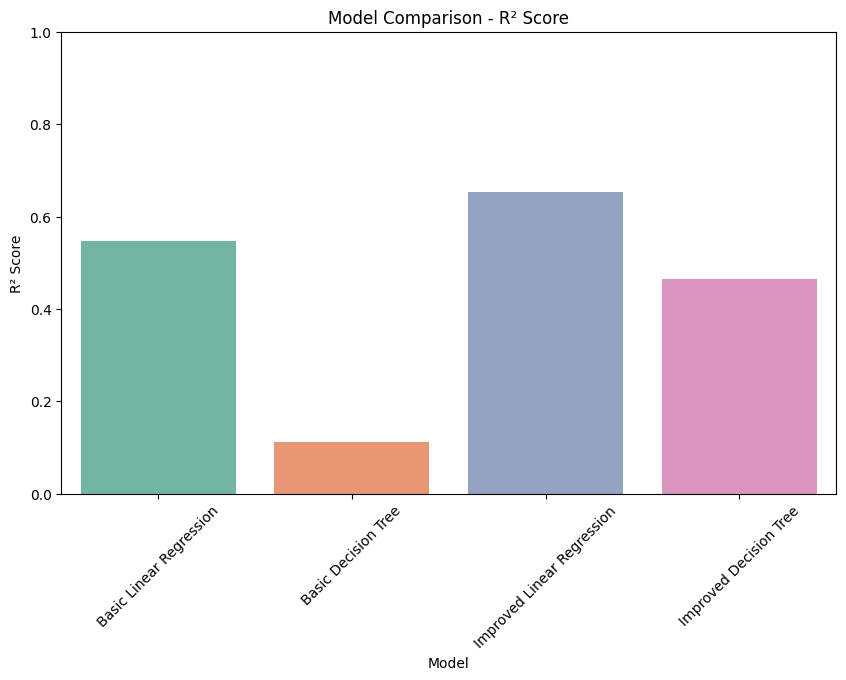

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="R2 Score", data=model_results, hue="Model", palette="Set2", legend=False)
plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Set y-axis limits for better visualization
plt.show()

The Improved Linear Regression model performed best overall. It achieved the highest R² score and the lowest RMSE, meaning it explained the most variation in house prices and made the smallest prediction errors. Adding categorical features improved both models, showing that feature engineering has a major impact on regression model performance.

## 12. Final Findings

This project focused on building regression models to predict house prices using property features.

Key findings:

- The dataset contains 545 rows and 13 columns.
- The target column for prediction is `price`.
- The strongest numeric correlation with `price` was `area`, followed by `bathrooms`, `stories`, `parking`, and `bedrooms`.
- The dataset did not contain missing values, so no missing-value imputation was needed.
- The first version of the models used only numeric features.
- Basic Linear Regression achieved an R² score of about 0.55.
- Basic Decision Tree Regressor achieved an R² score of about 0.11.
- After adding categorical features with one-hot encoding, both models improved.
- Improved Linear Regression achieved the best performance with an R² score of about 0.65 and RMSE of about 1.32 million.
- Improved Decision Tree Regressor also improved, reaching an R² score of about 0.47.
- The best model in this project was the Improved Linear Regression model.

Overall, this project showed that feature selection and categorical feature encoding can significantly improve regression model performance. It also demonstrated the basic regression workflow: data exploration, feature selection, train/test splitting, model training, evaluation, improvement, and comparison.